Dataset Shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

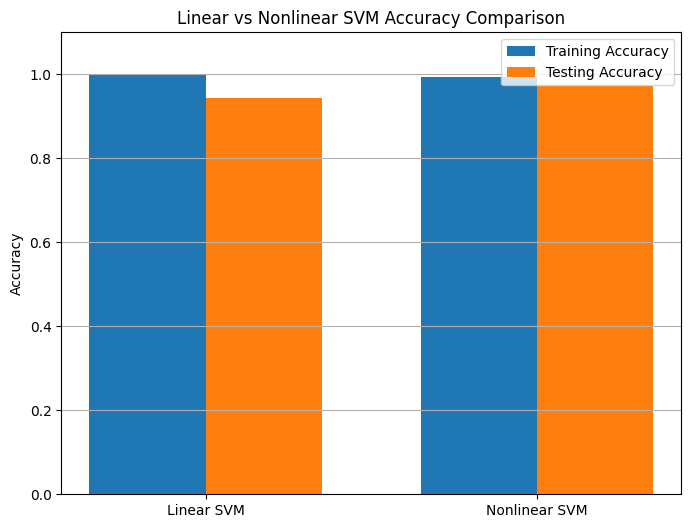

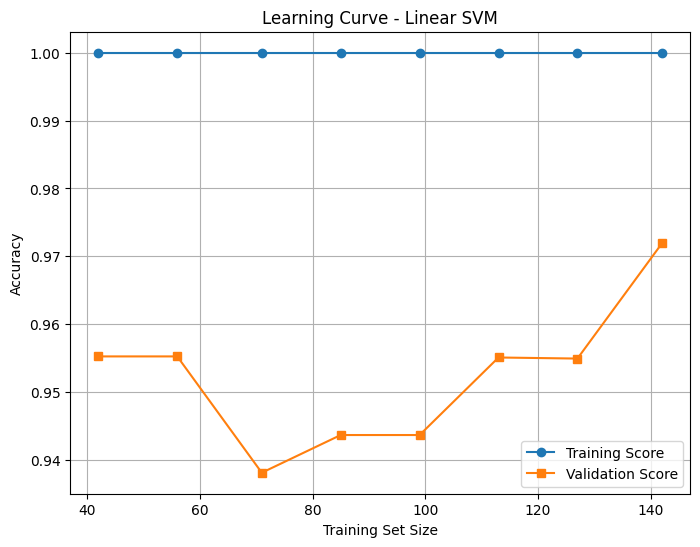

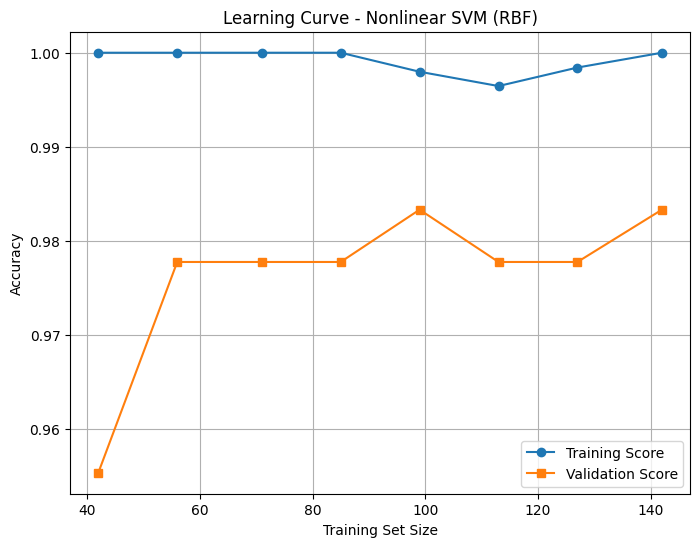


LINEAR SVM - C VALUE COMPARISON
C Value     Train Acc      Test Acc       Remarks
0.01        0.9930         1.0000         Balanced
0.1         0.9930         0.9722         Balanced
1           1.0000         0.9444         Balanced
10          1.0000         0.9444         Balanced
100         1.0000         0.9444         Balanced

NONLINEAR SVM (RBF) - C VALUE COMPARISON
C Value     Train Acc      Test Acc       Remarks
0.01        0.4014         0.3889         Underfitting
0.1         0.9859         0.9722         Balanced
1           0.9930         0.9722         Balanced
10          1.0000         0.9444         Balanced
100         1.0000         0.9444         Balanced

NONLINEAR SVM (RBF) - GAMMA VALUE COMPARISON
Gamma       Train Acc      Test Acc       Remarks
0.001       0.8803         0.8611         Balanced
0.01        0.9930         1.0000         Balanced
0.1         1.0000         0.9722         Balanced
1           1.0000         0.5556         Overfitting
10      

In [3]:
# Programming Assignment 35
# Implementing Linear and Nonlinear Support Vector Machine
# Dataset used: Wine Dataset
# Considering bias, variance, overfitting and underfitting issues

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())
print("\nTarget Class Counts:")
print(y.value_counts())

# --------------------------------------------------
# 2. Split dataset into training and testing sets
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------------------------------
# 3. Standardize features
# --------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = StandardScaler().fit_transform(X)

# --------------------------------------------------
# 4. Train Linear SVM
# --------------------------------------------------
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 5. Train Nonlinear SVM (RBF Kernel)
# --------------------------------------------------
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 6. Predictions
# --------------------------------------------------
y_train_pred_linear = linear_svm.predict(X_train_scaled)
y_test_pred_linear = linear_svm.predict(X_test_scaled)

y_train_pred_rbf = rbf_svm.predict(X_train_scaled)
y_test_pred_rbf = rbf_svm.predict(X_test_scaled)

# --------------------------------------------------
# 7. Accuracy Calculation
# --------------------------------------------------
train_acc_linear = accuracy_score(y_train, y_train_pred_linear)
test_acc_linear = accuracy_score(y_test, y_test_pred_linear)

train_acc_rbf = accuracy_score(y_train, y_train_pred_rbf)
test_acc_rbf = accuracy_score(y_test, y_test_pred_rbf)

print("\n" + "=" * 60)
print("LINEAR SVM RESULTS")
print("=" * 60)
print("Training Accuracy :", round(train_acc_linear, 4))
print("Testing Accuracy  :", round(test_acc_linear, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_linear))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_linear))

print("\n" + "=" * 60)
print("NONLINEAR SVM (RBF) RESULTS")
print("=" * 60)
print("Training Accuracy :", round(train_acc_rbf, 4))
print("Testing Accuracy  :", round(test_acc_rbf, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rbf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rbf))

# --------------------------------------------------
# 8. Bias, Variance, Overfitting, Underfitting Analysis Function
# --------------------------------------------------
def analyze_model(train_acc, test_acc, model_name):
    print("\n" + "-" * 60)
    print(f"Analysis for {model_name}")
    print("-" * 60)
    print("Training Accuracy :", round(train_acc, 4))
    print("Testing Accuracy  :", round(test_acc, 4))
    print("Difference        :", round(abs(train_acc - test_acc), 4))

    if train_acc < 0.80 and test_acc < 0.80:
        print("HIGH BIAS -> Model is likely UNDERFITTING")
    elif (train_acc - test_acc) > 0.10:
        print("HIGH VARIANCE -> Model is likely OVERFITTING")
    else:
        print("Model has a reasonable bias-variance balance")

analyze_model(train_acc_linear, test_acc_linear, "Linear SVM")
analyze_model(train_acc_rbf, test_acc_rbf, "Nonlinear SVM (RBF)")

# --------------------------------------------------
# 9. Compare both models
# --------------------------------------------------
comparison_df = pd.DataFrame({
    "Model": ["Linear SVM", "Nonlinear SVM (RBF)"],
    "Training Accuracy": [train_acc_linear, train_acc_rbf],
    "Testing Accuracy": [test_acc_linear, test_acc_rbf],
    "Difference": [abs(train_acc_linear - test_acc_linear), abs(train_acc_rbf - test_acc_rbf)]
})

print("\nModel Comparison:")
print(comparison_df)

# --------------------------------------------------
# 10. Bar chart for comparison
# --------------------------------------------------
plt.figure(figsize=(8, 6))
models = ["Linear SVM", "Nonlinear SVM"]
train_scores = [train_acc_linear, train_acc_rbf]
test_scores = [test_acc_linear, test_acc_rbf]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Training Accuracy')
plt.bar(x + width/2, test_scores, width, label='Testing Accuracy')

plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Linear vs Nonlinear SVM Accuracy Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()

from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import StratifiedKFold

# --------------------------------------------------
# 11. Learning Curve for Linear SVM
# --------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes_linear, train_scores_linear, val_scores_linear = learning_curve(
    SVC(kernel='linear', C=1.0, random_state=42),
    X_scaled_full,
    y,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=np.linspace(0.3, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_scores_linear_mean = np.mean(train_scores_linear, axis=1)
val_scores_linear_mean = np.mean(val_scores_linear, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_linear, train_scores_linear_mean, marker='o', label='Training Score')
plt.plot(train_sizes_linear, val_scores_linear_mean, marker='s', label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 12. Learning Curve for Nonlinear SVM (RBF)
# --------------------------------------------------
train_sizes_rbf, train_scores_rbf, val_scores_rbf = learning_curve(
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    X_scaled_full,
    y,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=np.linspace(0.3, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_scores_rbf_mean = np.mean(train_scores_rbf, axis=1)
val_scores_rbf_mean = np.mean(val_scores_rbf, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_rbf, train_scores_rbf_mean, marker='o', label='Training Score')
plt.plot(train_sizes_rbf, val_scores_rbf_mean, marker='s', label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Nonlinear SVM (RBF)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# 13. Underfitting and Overfitting Study for Linear SVM using C values
# --------------------------------------------------
print("\n" + "=" * 70)
print("LINEAR SVM - C VALUE COMPARISON")
print("=" * 70)
print(f"{'C Value':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:
    model = SVC(kernel='linear', C=c, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.80 and te_acc < 0.80:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{c:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")

# --------------------------------------------------
# 14. Underfitting and Overfitting Study for RBF SVM using C values
# --------------------------------------------------
print("\n" + "=" * 70)
print("NONLINEAR SVM (RBF) - C VALUE COMPARISON")
print("=" * 70)
print(f"{'C Value':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

for c in c_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.80 and te_acc < 0.80:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{c:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")

# --------------------------------------------------
# 15. Underfitting and Overfitting Study for RBF SVM using gamma values
# --------------------------------------------------
print("\n" + "=" * 70)
print("NONLINEAR SVM (RBF) - GAMMA VALUE COMPARISON")
print("=" * 70)
print(f"{'Gamma':<12}{'Train Acc':<15}{'Test Acc':<15}{'Remarks'}")

gamma_values = [0.001, 0.01, 0.1, 1, 10]

for g in gamma_values:
    model = SVC(kernel='rbf', C=1.0, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    if tr_acc < 0.80 and te_acc < 0.80:
        remark = "Underfitting"
    elif (tr_acc - te_acc) > 0.10:
        remark = "Overfitting"
    else:
        remark = "Balanced"

    print(f"{g:<12}{tr_acc:<15.4f}{te_acc:<15.4f}{remark}")